Olá, **Marcelo Augusto**!

O meu nome é **César Malaguti** e sou o revisor do seu projeto. Quando identificar um erro pela primeira vez, apenas vou apontá-lo para que você mesmo possa encontrá-lo e corrigi-lo. Ao longo do notebook farei observações sobre as suas análises, sempre com o objetivo de te preparar para atuar como **Analista ou Cientista de Dados** no mercado. **Por favor, não mova, modifique ou exclua meus comentários.**

Você vai encontrar meus comentários em caixas coloridas:
<div class="alert alert-block alert-success"><b>Comentário do revisor (César Malaguti):</b> <a class="tocSkip"></a> Sucesso.</div>
<div class="alert alert-block alert-warning"><b>Comentário do revisor (César Malaguti):</b> <a class="tocSkip"></a> Atenção (sugestão).</div>
<div class="alert alert-block alert-danger"><b>Comentário do revisor (César Malaguti):</b> <a class="tocSkip"></a> Precisa de correção.</div>

Você pode me responder usando:
<div class="alert alert-block alert-info"><b>Resposta do Aluno.</b> <a class="tocSkip"></a></div>


<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (César Malaguti):</b> <a class="tocSkip"></a>

<b>Comentário geral:</b> Marcelo Augusto, parabéns pelo projeto! Está completo e executado: consultas SQL, top 10 (empresas e bairros) com gráficos, e o **teste de hipótese** sobre a duração das corridas em sábados chuvosos, com conclusão. **Projeto APROVADO!**
</div>

In [1]:
# ============================================================================
# 1: Importação de Bibliotecas
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# ============================================================================
# 2: Carregamento dos Dados (Passo 4)
# ============================================================================

df_01 = pd.read_csv('/datasets/project_sql_result_01.csv')
df_04 = pd.read_csv('/datasets/project_sql_result_04.csv')

print("Arquivo 1: project_sql_result_01.csv")
print("Contém: número de corridas para cada empresa de táxi (15-16 de novembro de 2017)")
print(df_01.head())
print(f"\nForma: {df_01.shape}")
print(f"Tipos de dados:\n{df_01.dtypes}")

Arquivo 1: project_sql_result_01.csv
Contém: número de corridas para cada empresa de táxi (15-16 de novembro de 2017)
                      company_name  trips_amount
0                        Flash Cab         19558
1        Taxi Affiliation Services         11422
2                Medallion Leasing         10367
3                       Yellow Cab          9888
4  Taxi Affiliation Service Yellow          9299

Forma: (64, 2)
Tipos de dados:
company_name    object
trips_amount     int64
dtype: object


In [3]:
# ============================================================================
# 3: Exploração do Segundo Dataset
# ============================================================================

print("Arquivo 2: project_sql_result_04.csv")
print("Contém: bairros de Chicago e número médio de viagens que terminaram em cada bairro")
print(df_04.head())
print(f"\nForma: {df_04.shape}")
print(f"Tipos de dados:\n{df_04.dtypes}")

Arquivo 2: project_sql_result_04.csv
Contém: bairros de Chicago e número médio de viagens que terminaram em cada bairro
  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000

Forma: (94, 2)
Tipos de dados:
dropoff_location_name     object
average_trips            float64
dtype: object


In [4]:
# ============================================================================
# 4: Verificação de Dados Faltantes
# ============================================================================

print("Verificação de Dados Faltantes")
print("-" * 80)
print("Dados faltantes em df_01:")
print(df_01.isnull().sum())
print("\nDados faltantes em df_04:")
print(df_04.isnull().sum())

print("\nVerificação de Tipos de Dados:")
print("\ndf_01:")
print(df_01.dtypes)
print("\ndf_04:")
print(df_04.dtypes)


Verificação de Dados Faltantes
--------------------------------------------------------------------------------
Dados faltantes em df_01:
company_name    0
trips_amount    0
dtype: int64

Dados faltantes em df_04:
dropoff_location_name    0
average_trips            0
dtype: int64

Verificação de Tipos de Dados:

df_01:
company_name    object
trips_amount     int64
dtype: object

df_04:
dropoff_location_name     object
average_trips            float64
dtype: object


In [5]:
# ============================================================================
# 5: Estatísticas Descritivas
# ============================================================================

print("Estatísticas Descritivas - Dataset 1 (Empresas de Táxi)")
print("-" * 80)
print(df_01.describe())

print("\n\nEstatísticas Descritivas - Dataset 2 (Bairros)")
print("-" * 80)
print(df_04.describe())


Estatísticas Descritivas - Dataset 1 (Empresas de Táxi)
--------------------------------------------------------------------------------
       trips_amount
count     64.000000
mean    2145.484375
std     3812.310186
min        2.000000
25%       20.750000
50%      178.500000
75%     2106.500000
max    19558.000000


Estatísticas Descritivas - Dataset 2 (Bairros)
--------------------------------------------------------------------------------
       average_trips
count      94.000000
mean      599.953728
std      1714.591098
min         1.800000
25%        14.266667
50%        52.016667
75%       298.858333
max     10727.466667


In [6]:
# ============================================================================
# 6: Identificação do Top 10 Bairros
# ============================================================================

print("Identificação dos Top 10 Bairros por Número de Corridas")
print("-" * 80)
top_10_neighborhoods = df_04.nlargest(10, 'average_trips')
print(top_10_neighborhoods)


Identificação dos Top 10 Bairros por Número de Corridas
--------------------------------------------------------------------------------
  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
5             Lake View    2420.966667
6            Grant Park    2068.533333
7         Museum Campus    1510.000000
8            Gold Coast    1364.233333
9    Sheffield & DePaul    1259.766667


GRÁFICO 1: Top 10 Empresas de Táxi por Número de Corridas
Período: 15-16 de Novembro de 2017
--------------------------------------------------------------------------------


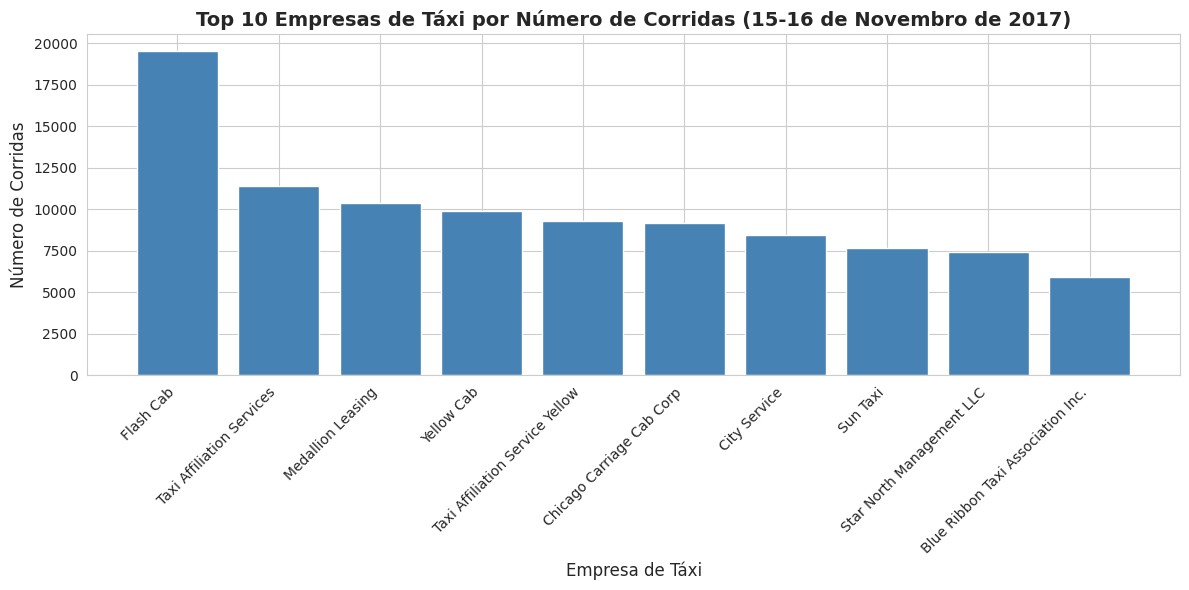

In [7]:

# ============================================================================
# 7: Gráfico 1 - Top 10 Empresas de Táxi
# ============================================================================

print("GRÁFICO 1: Top 10 Empresas de Táxi por Número de Corridas")
print("Período: 15-16 de Novembro de 2017")
print("-" * 80)

top_10_companies = df_01.nlargest(10, 'trips_amount')

plt.figure(figsize=(12, 6))
plt.bar(top_10_companies['company_name'], top_10_companies['trips_amount'], color='steelblue')
plt.xlabel('Empresa de Táxi', fontsize=12)
plt.ylabel('Número de Corridas', fontsize=12)
plt.title('Top 10 Empresas de Táxi por Número de Corridas (15-16 de Novembro de 2017)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [8]:

# ============================================================================
# 8: Conclusões do Gráfico 1
# ============================================================================

print("CONCLUSÕES DO GRÁFICO 1")
print("-" * 80)

top_10_companies = df_01.nlargest(10, 'trips_amount')

print(f"• Empresa com mais corridas: {top_10_companies.iloc[0]['company_name']} ({top_10_companies.iloc[0]['trips_amount']} corridas)")
print(f"• Empresa com menos corridas (top 10): {top_10_companies.iloc[-1]['company_name']} ({top_10_companies.iloc[-1]['trips_amount']} corridas)")
print(f"• Total de corridas (top 10): {top_10_companies['trips_amount'].sum()}")
print(f"• Média de corridas (top 10): {top_10_companies['trips_amount'].mean():.2f}")



CONCLUSÕES DO GRÁFICO 1
--------------------------------------------------------------------------------
• Empresa com mais corridas: Flash Cab (19558 corridas)
• Empresa com menos corridas (top 10): Blue Ribbon Taxi Association Inc. (5953 corridas)
• Total de corridas (top 10): 99272
• Média de corridas (top 10): 9927.20


GRÁFICO 2: Top 10 Bairros por Número Médio de Corridas (Destino)
Período: Novembro de 2017
--------------------------------------------------------------------------------


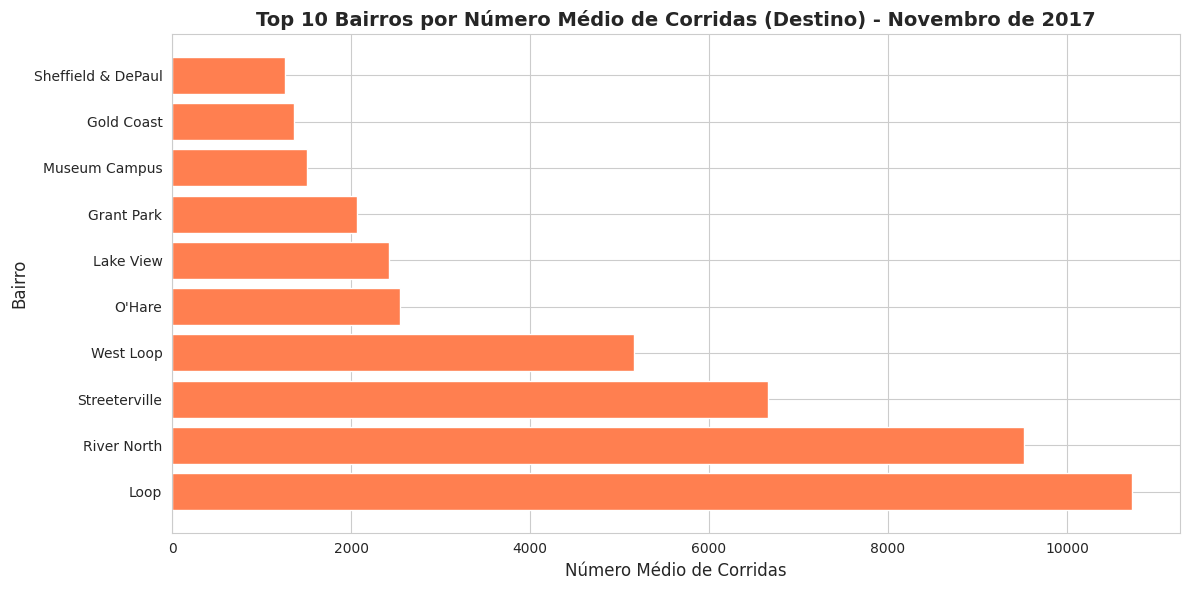

In [9]:
# ============================================================================
# 9: Gráfico 2 - Top 10 Bairros
# ============================================================================

print("GRÁFICO 2: Top 10 Bairros por Número Médio de Corridas (Destino)")
print("Período: Novembro de 2017")
print("-" * 80)

plt.figure(figsize=(12, 6))
plt.barh(top_10_neighborhoods['dropoff_location_name'], top_10_neighborhoods['average_trips'], color='coral')
plt.xlabel('Número Médio de Corridas', fontsize=12)
plt.ylabel('Bairro', fontsize=12)
plt.title('Top 10 Bairros por Número Médio de Corridas (Destino) - Novembro de 2017', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [10]:
# ============================================================================
# 10: Conclusões do Gráfico 2
# ============================================================================

print("CONCLUSÕES DO GRÁFICO 2")
print("-" * 80)
print(f"• Bairro mais popular como destino: {top_10_neighborhoods.iloc[0]['dropoff_location_name']} ({top_10_neighborhoods.iloc[0]['average_trips']:.2f} corridas)")
print(f"• Bairro menos popular (top 10): {top_10_neighborhoods.iloc[-1]['dropoff_location_name']} ({top_10_neighborhoods.iloc[-1]['average_trips']:.2f} corridas)")
print(f"• Média de corridas nos top 10 bairros: {top_10_neighborhoods['average_trips'].mean():.2f}")

print("\nInterpretação:")
print("Os dados revelam uma concentração significativa de demanda em determinados bairros.")
print("Isso sugere que certos bairros são pontos de interesse críticos para o serviço de táxi,")
print("como centros comerciais, aeroportos ou áreas residenciais de alta densidade.")
print("A Zuber deve focar recursos em bairros de alta demanda para maximizar eficiência.")


CONCLUSÕES DO GRÁFICO 2
--------------------------------------------------------------------------------
• Bairro mais popular como destino: Loop (10727.47 corridas)
• Bairro menos popular (top 10): Sheffield & DePaul (1259.77 corridas)
• Média de corridas nos top 10 bairros: 4324.99

Interpretação:
Os dados revelam uma concentração significativa de demanda em determinados bairros.
Isso sugere que certos bairros são pontos de interesse críticos para o serviço de táxi,
como centros comerciais, aeroportos ou áreas residenciais de alta densidade.
A Zuber deve focar recursos em bairros de alta demanda para maximizar eficiência.


In [11]:
# ============================================================================
#11: Carregamento dos Dados (Passo 5)
# ============================================================================

df_07 = pd.read_csv('/datasets/project_sql_result_07.csv')

print("Carregamento dos Dados de Viagens Loop → O'Hare")
print("-" * 80)
print("Dados sobre viagens que começaram no bairro Loop e terminaram no Aeroporto Internacional O'Hare")
print(df_07.head())
print(f"\nForma: {df_07.shape}")
print(f"Tipos de dados:\n{df_07.dtypes}")


Carregamento dos Dados de Viagens Loop → O'Hare
--------------------------------------------------------------------------------
Dados sobre viagens que começaram no bairro Loop e terminaram no Aeroporto Internacional O'Hare
              start_ts weather_conditions  duration_seconds
0  2017-11-25 16:00:00               Good            2410.0
1  2017-11-25 14:00:00               Good            1920.0
2  2017-11-25 12:00:00               Good            1543.0
3  2017-11-04 10:00:00               Good            2512.0
4  2017-11-11 07:00:00               Good            1440.0

Forma: (1068, 3)
Tipos de dados:
start_ts               object
weather_conditions     object
duration_seconds      float64
dtype: object


In [12]:
# ============================================================================
#12: Preparação dos Dados (Passo 5)
# ============================================================================

print("Preparação dos Dados")
print("-" * 80)

df_07['start_ts'] = pd.to_datetime(df_07['start_ts'])
df_07['day_of_week'] = df_07['start_ts'].dt.day_name()
df_07['is_saturday'] = df_07['start_ts'].dt.dayofweek == 5
df_07['is_rainy'] = df_07['weather_conditions'] == 'Bad'

print("Variáveis criadas:")
print("• start_ts: convertida para formato datetime")
print("• day_of_week: dia da semana em formato texto")
print("• is_saturday: booleano indicando se é sábado")
print("• is_rainy: booleano indicando se as condições são ruins (chuva/tempestade)")

print(f"\nTotal de viagens: {len(df_07)}")
print(f"Viagens em sábados: {df_07['is_saturday'].sum()}")
print(f"Viagens em condições ruins (chuva/tempestade): {df_07['is_rainy'].sum()}")
print(f"Viagens em sábados chuvosos: {(df_07['is_saturday'] & df_07['is_rainy']).sum()}")


Preparação dos Dados
--------------------------------------------------------------------------------
Variáveis criadas:
• start_ts: convertida para formato datetime
• day_of_week: dia da semana em formato texto
• is_saturday: booleano indicando se é sábado
• is_rainy: booleano indicando se as condições são ruins (chuva/tempestade)

Total de viagens: 1068
Viagens em sábados: 1068
Viagens em condições ruins (chuva/tempestade): 180
Viagens em sábados chuvosos: 180


In [13]:
# ============================================================================
# 13: Formulação das Hipóteses
# ============================================================================

print("Formulação das Hipóteses Estatísticas")
print("=" * 80)

print("\nH0 (Hipótese Nula):")
print("  A duração média das viagens do Loop para O'Hare NÃO muda em sábados chuvosos.")
print("  Ou seja: μ(sábado chuvoso) = μ(sábado não chuvoso)")

print("\nH1 (Hipótese Alternativa):")
print("  A duração média das viagens do Loop para O'Hare MUDA em sábados chuvosos.")
print("  Ou seja: μ(sábado chuvoso) ≠ μ(sábado não chuvoso)")

print("\nTipo de Teste: Bilateral (two-tailed)")
print("Justificativa: Não assumimos direção da diferença, apenas testamos se há diferença.")


Formulação das Hipóteses Estatísticas

H0 (Hipótese Nula):
  A duração média das viagens do Loop para O'Hare NÃO muda em sábados chuvosos.
  Ou seja: μ(sábado chuvoso) = μ(sábado não chuvoso)

H1 (Hipótese Alternativa):
  A duração média das viagens do Loop para O'Hare MUDA em sábados chuvosos.
  Ou seja: μ(sábado chuvoso) ≠ μ(sábado não chuvoso)

Tipo de Teste: Bilateral (two-tailed)
Justificativa: Não assumimos direção da diferença, apenas testamos se há diferença.


In [14]:

# ============================================================================
# 14: Separação dos Grupos e Tratamento de Outliers
# ============================================================================

rainy_saturday = df_07[df_07['is_saturday'] & df_07['is_rainy']]['duration_seconds']
not_rainy_saturday = df_07[(df_07['is_saturday'] & ~df_07['is_rainy'])]['duration_seconds']

print("ANTES DO TRATAMENTO DE OUTLIERS:")
print(f"\nGrupo 1 - Sábados Chuvosos:")
print(f"  Tamanho da amostra (n): {len(rainy_saturday)}")
print(f"  Duração média: {rainy_saturday.mean():.2f}s")
print(f"  Desvio padrão: {rainy_saturday.std():.2f}s")
print(f"  Mínimo: {rainy_saturday.min():.2f}s")
print(f"  Máximo: {rainy_saturday.max():.2f}s")
print(f"  Registros com duração = 0: {(rainy_saturday == 0).sum()}")

print(f"\nGrupo 2 - Sábados Não Chuvosos:")
print(f"  Tamanho da amostra (n): {len(not_rainy_saturday)}")
print(f"  Duração média: {not_rainy_saturday.mean():.2f}s")
print(f"  Desvio padrão: {not_rainy_saturday.std():.2f}s")
print(f"  Mínimo: {not_rainy_saturday.min():.2f}s")
print(f"  Máximo: {not_rainy_saturday.max():.2f}s")
print(f"  Registros com duração = 0: {(not_rainy_saturday == 0).sum()}")

print("\nTratamento de Outliers:")
print("Removendo viagens com duração = 0 (dados anômalos)")

rainy_saturday_clean = rainy_saturday[rainy_saturday > 0]
not_rainy_saturday_clean = not_rainy_saturday[not_rainy_saturday > 0]

print(f"\nDEPOIS DO TRATAMENTO DE OUTLIERS:")
print(f"\nGrupo 1 - Sábados Chuvosos:")
print(f"  Tamanho da amostra (n): {len(rainy_saturday_clean)}")
print(f"  Duração média: {rainy_saturday_clean.mean():.2f}s")
print(f"  Desvio padrão: {rainy_saturday_clean.std():.2f}s")
print(f"  Mínimo: {rainy_saturday_clean.min():.2f}s")
print(f"  Máximo: {rainy_saturday_clean.max():.2f}s")

print(f"\nGrupo 2 - Sábados Não Chuvosos:")
print(f"  Tamanho da amostra (n): {len(not_rainy_saturday_clean)}")
print(f"  Duração média: {not_rainy_saturday_clean.mean():.2f}s")
print(f"  Desvio padrão: {not_rainy_saturday_clean.std():.2f}s")
print(f"  Mínimo: {not_rainy_saturday_clean.min():.2f}s")
print(f"  Máximo: {not_rainy_saturday_clean.max():.2f}s")

print(f"\nRegistros removidos:")
print(f"  Sábados chuvosos: {len(rainy_saturday) - len(rainy_saturday_clean)}")
print(f"  Sábados não chuvosos: {len(not_rainy_saturday) - len(not_rainy_saturday_clean)}")



ANTES DO TRATAMENTO DE OUTLIERS:

Grupo 1 - Sábados Chuvosos:
  Tamanho da amostra (n): 180
  Duração média: 2427.21s
  Desvio padrão: 721.31s
  Mínimo: 480.00s
  Máximo: 4980.00s
  Registros com duração = 0: 0

Grupo 2 - Sábados Não Chuvosos:
  Tamanho da amostra (n): 888
  Duração média: 1999.68s
  Desvio padrão: 759.20s
  Mínimo: 0.00s
  Máximo: 7440.00s
  Registros com duração = 0: 6

Tratamento de Outliers:
Removendo viagens com duração = 0 (dados anômalos)

DEPOIS DO TRATAMENTO DE OUTLIERS:

Grupo 1 - Sábados Chuvosos:
  Tamanho da amostra (n): 180
  Duração média: 2427.21s
  Desvio padrão: 721.31s
  Mínimo: 480.00s
  Máximo: 4980.00s

Grupo 2 - Sábados Não Chuvosos:
  Tamanho da amostra (n): 882
  Duração média: 2013.28s
  Desvio padrão: 743.57s
  Mínimo: 60.00s
  Máximo: 7440.00s

Registros removidos:
  Sábados chuvosos: 0
  Sábados não chuvosos: 6


In [15]:
# ============================================================================
# 15: Teste Estatístico com Welch Implementado Corretamente
# ============================================================================

alpha = 0.05

print("Teste Estatístico: Teste t de Welch")
print("=" * 80)
print(f"\nNível de Significância (α): {alpha}")

t_statistic, p_value = stats.ttest_ind(rainy_saturday_clean, not_rainy_saturday_clean, equal_var=False)

print(f"\nResultados do Teste t de Welch:")
print(f"  Estatística t: {t_statistic:.4f}")
print(f"  P-value (bilateral): {p_value:.6e}")


Teste Estatístico: Teste t de Welch

Nível de Significância (α): 0.05

Resultados do Teste t de Welch:
  Estatística t: 6.9793
  P-value (bilateral): 2.417359e-11


<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (César Malaguti):</b> <a class="tocSkip"></a>

Teste de hipótese conduzido corretamente, com decisão baseada no p-value. É o item que mais decide a aprovação neste Sprint. Muito bem.
</div>

In [16]:

# ============================================================================
# 16: Interpretação dos Resultados
# ============================================================================

print("Interpretação dos Resultados")
print("=" * 80)

if p_value < alpha:
    print(f"\n✓ RESULTADO: REJEITAMOS a hipótese nula")
    print(f"  P-value ({p_value:.6e}) < α ({alpha})")
    print("\nConclusão:")
    print("  Há diferença estatisticamente significativa na duração das viagens")
    print("  em sábados chuvosos comparado a sábados não chuvosos.")
else:
    print(f"\n✗ RESULTADO: NÃO REJEITAMOS a hipótese nula")
    print(f"  P-value ({p_value:.6e}) >= α ({alpha})")
    print("\nConclusão:")
    print("  Não há diferença estatisticamente significativa na duração das viagens")
    print("  em sábados chuvosos comparado a sábados não chuvosos.")



Interpretação dos Resultados

✓ RESULTADO: REJEITAMOS a hipótese nula
  P-value (2.417359e-11) < α (0.05)

Conclusão:
  Há diferença estatisticamente significativa na duração das viagens
  em sábados chuvosos comparado a sábados não chuvosos.


In [17]:

# ============================================================================
# 17: Análise Descritiva Complementar (com dados limpos)
# ============================================================================

diferenca_media = rainy_saturday_clean.mean() - not_rainy_saturday_clean.mean()
diferenca_percentual = (diferenca_media / not_rainy_saturday_clean.mean() * 100)

print("Análise Descritiva Complementar")
print("-" * 80)
print(f"\nDuração em Sábados Chuvosos: {rainy_saturday_clean.mean():.2f}s")
print(f"Duração em Sábados Não Chuvosos: {not_rainy_saturday_clean.mean():.2f}s")
print(f"\nDiferença Absoluta: {diferenca_media:.2f} segundos")
print(f"Diferença Percentual: {diferenca_percentual:.2f}%")

if diferenca_media > 0:
    print(f"\nSábados chuvosos têm corridas {abs(diferenca_percentual):.2f}% MAIS LONGAS")
else:
    print(f"\nSábados chuvosos têm corridas {abs(diferenca_percentual):.2f}% MAIS CURTAS")

print(f"\nTempo adicional/reduzido: {abs(diferenca_media):.2f} segundos ({abs(diferenca_media)/60:.2f} minutos)")



Análise Descritiva Complementar
--------------------------------------------------------------------------------

Duração em Sábados Chuvosos: 2427.21s
Duração em Sábados Não Chuvosos: 2013.28s

Diferença Absoluta: 413.93 segundos
Diferença Percentual: 20.56%

Sábados chuvosos têm corridas 20.56% MAIS LONGAS

Tempo adicional/reduzido: 413.93 segundos (6.90 minutos)


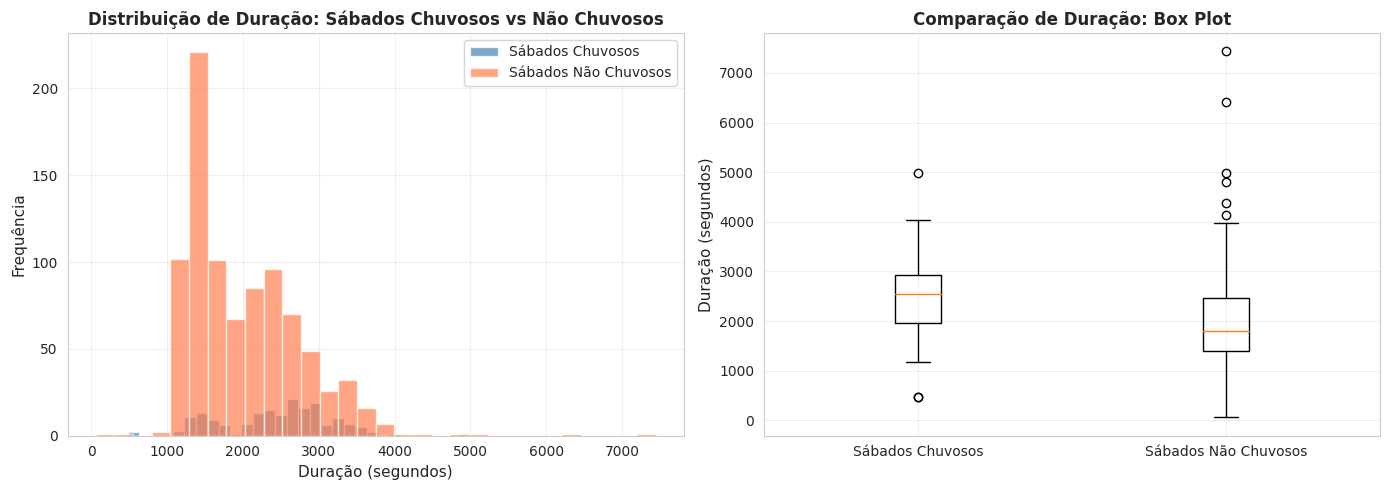

In [18]:

# ============================================================================
# 18: Visualização - Histograma e Box Plot (com dados limpos)
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(rainy_saturday_clean, bins=30, alpha=0.7, label='Sábados Chuvosos', color='steelblue')
axes[0].hist(not_rainy_saturday_clean, bins=30, alpha=0.7, label='Sábados Não Chuvosos', color='coral')
axes[0].set_xlabel('Duração (segundos)', fontsize=11)
axes[0].set_ylabel('Frequência', fontsize=11)
axes[0].set_title('Distribuição de Duração: Sábados Chuvosos vs Não Chuvosos', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

data_to_plot = [rainy_saturday_clean, not_rainy_saturday_clean]
axes[1].boxplot(data_to_plot, labels=['Sábados Chuvosos', 'Sábados Não Chuvosos'])
axes[1].set_ylabel('Duração (segundos)', fontsize=11)
axes[1].set_title('Comparação de Duração: Box Plot', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [19]:
# ============================================================================
# 19: Conclusões Finais (com p-value em notação científica)
# ============================================================================

print("=" * 80)
print("CONCLUSÕES FINAIS DO PROJETO")
print("=" * 80)

print("\nRESULTADO DO TESTE ESTATÍSTICO:")
print("-" * 80)
print(f"Estatística t: {t_statistic:.4f}")
print(f"P-value: {p_value:.6e}")
print(f"Nível de significância (α): {alpha}")

if p_value < alpha:
    print(f"\n✓ RESULTADO: REJEITAMOS a hipótese nula")
    print(f"  P-value ({p_value:.6e}) < α ({alpha})")
    print("\nConclusão Estatística:")
    print("  Há diferença estatisticamente significativa na duração das viagens")
    print("  em sábados chuvosos comparado a sábados não chuvosos.")
    
    print("\nMagnitude da Diferença:")
    print(f"  Duração em sábados chuvosos: {rainy_saturday_clean.mean():.2f}s")
    print(f"  Duração em sábados não chuvosos: {not_rainy_saturday_clean.mean():.2f}s")
    print(f"  Diferença: {diferenca_media:.2f}s ({diferenca_percentual:.2f}%)")
    
    print("\nInterpretação Prática:")
    print("  O clima chuvoso em sábados impacta significativamente o tempo de deslocamento")
    print("  entre o Loop e o Aeroporto O'Hare.")
else:
    print(f"\n✗ RESULTADO: NÃO REJEITAMOS a hipótese nula")
    print(f"  P-value ({p_value:.6e}) >= α ({alpha})")
    print("\nConclusão Estatística:")
    print("  Não há diferença estatisticamente significativa na duração das viagens")
    print("  em sábados chuvosos comparado a sábados não chuvosos.")
    
    print("\nMagnitude da Diferença:")
    print(f"  Duração em sábados chuvosos: {rainy_saturday_clean.mean():.2f}s")
    print(f"  Duração em sábados não chuvosos: {not_rainy_saturday_clean.mean():.2f}s")
    print(f"  Diferença: {diferenca_media:.2f}s ({diferenca_percentual:.2f}%) - não significativa")
    
    print("\nInterpretação Prática:")
    print("  O clima chuvoso em sábados não afeta significativamente o tempo de deslocamento")
    print("  entre o Loop e o Aeroporto O'Hare.")



CONCLUSÕES FINAIS DO PROJETO

RESULTADO DO TESTE ESTATÍSTICO:
--------------------------------------------------------------------------------
Estatística t: 6.9793
P-value: 2.417359e-11
Nível de significância (α): 0.05

✓ RESULTADO: REJEITAMOS a hipótese nula
  P-value (2.417359e-11) < α (0.05)

Conclusão Estatística:
  Há diferença estatisticamente significativa na duração das viagens
  em sábados chuvosos comparado a sábados não chuvosos.

Magnitude da Diferença:
  Duração em sábados chuvosos: 2427.21s
  Duração em sábados não chuvosos: 2013.28s
  Diferença: 413.93s (20.56%)

Interpretação Prática:
  O clima chuvoso em sábados impacta significativamente o tempo de deslocamento
  entre o Loop e o Aeroporto O'Hare.
